In [7]:
from paint.drawV2 import *

成功加载 FLEC 的数据
成功加载 HiFlash 的数据
成功加载 FedAT 的数据
成功加载 FedBuff 的数据
保存图表: ./PK/Exp2025-V2-Cifar10-dir0.1/Exp2025-V2-Cifar10-dir0.1_accuracy_vs_epoch_2000_exponential_a0.1_wandb_style.png
保存图表: ./PK/Exp2025-V2-Cifar10-dir0.1/Exp2025-V2-Cifar10-dir0.1_loss_vs_epoch_2000_exponential_a0.1_wandb_style.png
保存图表: ./PK/Exp2025-V2-Cifar10-dir0.1/Exp2025-V2-Cifar10-dir0.1_accuracy_vs_time_2000_exponential_a0.1_wandb_style.png
绘图完成！


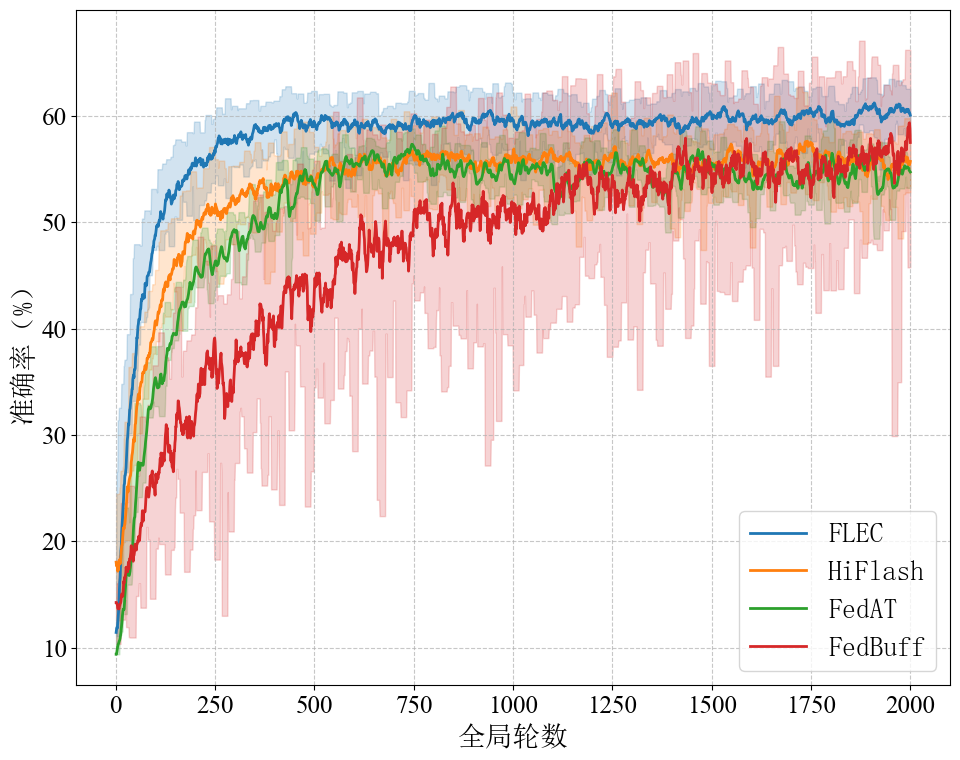

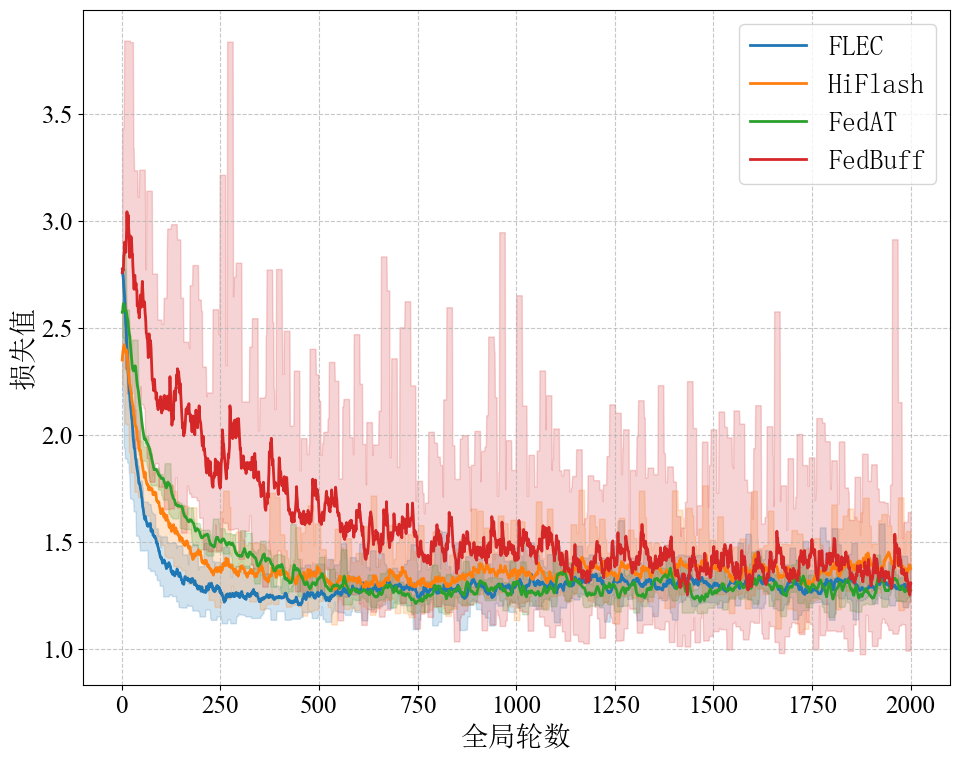

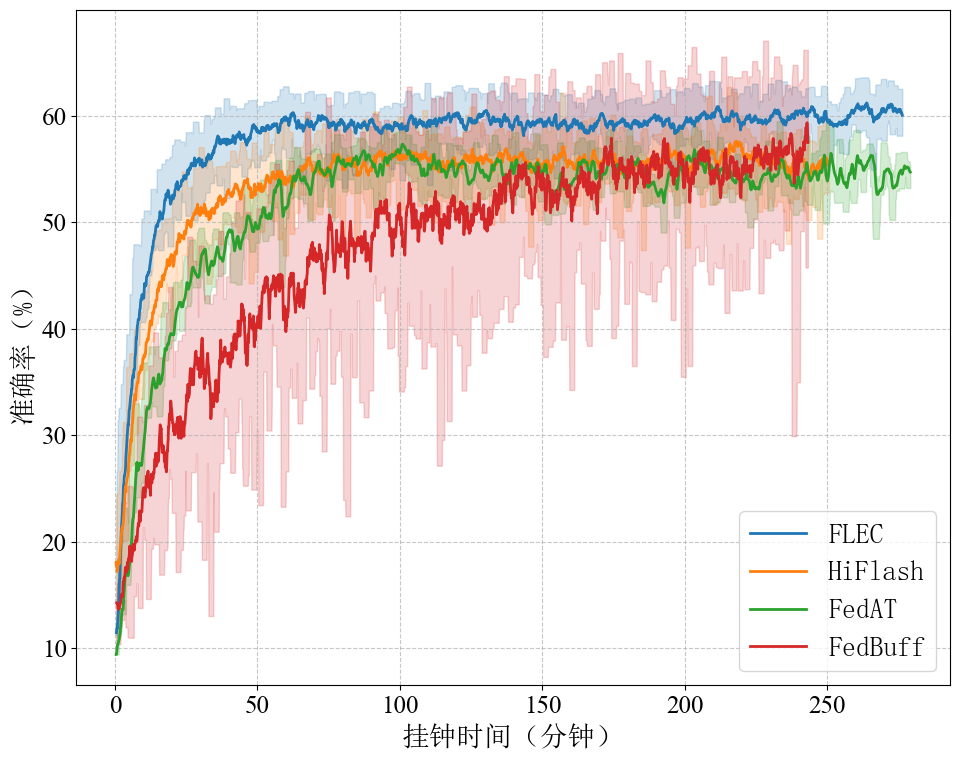

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import savgol_filter
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import re
from scipy.interpolate import make_interp_spline

# 自定义算法排序顺序
custom_order = ["FLEC", "HiFlash", "FedAT", "FedBuff"]

# 创建排序键函数
def custom_sort(item):
    # 对于列表中的项目，返回其索引
    for i, prefix in enumerate(custom_order):
        if item.startswith(prefix):
            return i
    # 对于不在列表中的项目，返回一个较大的数，使它们排在最后
    return len(custom_order)

# 1. 移动平均平滑法
def moving_average(data, window_size=5):
    """对数据进行移动平均平滑处理"""
    if window_size % 2 == 0:
        window_size += 1  # 确保窗口大小为奇数
    
    if len(data) < window_size:
        return data
    
    smoothed = []
    # 前半部分数据直接复制
    half_window = window_size // 2
    smoothed.extend(data[:half_window])
    
    # 中间部分使用移动平均
    for i in range(half_window, len(data) - half_window):
        window = data[i - half_window:i + half_window + 1]
        smoothed.append(sum(window) / len(window))
    
    # 后半部分数据直接复制
    smoothed.extend(data[-half_window:])
    
    return smoothed

# 2. 指数平滑法
def exponential_smoothing(data, alpha=0.3):
    """对数据进行指数平滑处理"""
    smoothed = []
    if not data:
        return smoothed
        
    # 第一个值不变
    smoothed.append(data[0])
    
    # 依次计算后续值的平滑结果
    for i in range(1, len(data)):
        smoothed_val = alpha * data[i] + (1 - alpha) * smoothed[i-1]
        smoothed.append(smoothed_val)
        
    return smoothed

# 3. Savitzky-Golay平滑滤波器
def savgol_smoothing(data, window_length=11, polyorder=3):
    """使用Savitzky-Golay滤波器进行平滑，适合保留峰值特征"""
    if len(data) < window_length:
        return data
        
    smoothed = savgol_filter(data, window_length, polyorder)
    return smoothed.tolist()

# 4. 高斯平滑滤波器
def gaussian_smoothing(data, sigma=2):
    """使用高斯滤波器进行平滑"""
    smoothed = gaussian_filter1d(data, sigma)
    return smoothed.tolist()

# 5. 计算原始数据的波动区间
def calculate_fluctuation(data, window_size=5):
    """
    计算数据的局部波动范围
    
    参数:
        data (list): 原始数据
        window_size (int): 局部窗口大小
        
    返回:
        tuple: (下界列表, 上界列表)
    """
    lower_bound = []
    upper_bound = []
    half_window = window_size // 2
    
    for i in range(len(data)):
        start_idx = max(0, i - half_window)
        end_idx = min(len(data), i + half_window + 1)
        window_data = data[start_idx:end_idx]
        
        local_min = min(window_data)
        local_max = max(window_data)
        
        lower_bound.append(local_min)
        upper_bound.append(local_max)
    
    return lower_bound, upper_bound

def plot_federated_learning_performance(
    main_dir, 
    max_epoch=500,  # 默认最大轮数
    max_time=90000000,    # 默认最大时间（分钟）
    save_dir=None,  # 保存图片的目录，默认为main_dir
    fig_size=(12, 8),
    dpi=150,
    dataset_name=None,  # 数据集名称，如果为None则从目录名提取
    dir_alpha=None,      # Dir参数值，如果为None则从目录名提取
    smooth_method=None,   # 平滑方法: None, 'exponential', 'moving_average', 'savgol', 'gaussian'
    smooth_params=None,   # 平滑参数字典，根据不同方法设置对应参数
    wandb_style=True,     # 使用Wandb风格的半透明区域
    area_alpha=0.2,       # 半透明区域的透明度
    fluctuation_window=11 # 波动区间的窗口大小
):
    """
    从各个联邦学习算法目录中读取性能数据并绘制对比图
    
    参数:
        main_dir (str): 主实验目录路径
        max_epoch (int): 要绘制的最大轮数
        max_time (int): 时间图的最大时间限制（分钟）
        save_dir (str): 保存图片的目录，默认为main_dir
        fig_size (tuple): 图表大小
        dpi (int): 图表DPI
        dataset_name (str): 数据集名称，如果为None则从目录名提取
        dir_alpha (str): Dir参数值，如果为None则从目录名提取
        smooth_method (str): 平滑方法：None表示不平滑，可选'exponential', 'moving_average', 'savgol', 'gaussian'
        smooth_params (dict): 平滑参数字典，根据选择的方法传入对应参数
        wandb_style (bool): 是否使用Wandb风格的半透明区域
        area_alpha (float): 半透明区域的透明度
        fluctuation_window (int): 计算波动区间的窗口大小
    """
    # 初始化平滑参数
    if smooth_params is None:
        smooth_params = {}
    
    # 如果未指定保存目录，使用主目录
    if save_dir is None:
        save_dir = main_dir
    
    # 如果未指定数据集名称和dir_alpha，从目录名提取
    if dataset_name is None or dir_alpha is None:
        dir_name = os.path.basename(main_dir)
        # 尝试从目录名解析数据集名称和dir值
        match = re.match(r".*-(\w+)-dir([\d\.]+)", dir_name)
        if match:
            dataset_name = match.group(1) if dataset_name is None else dataset_name
            dir_alpha = match.group(2) if dir_alpha is None else dir_alpha
        else:
            dataset_name = "Unknown" if dataset_name is None else dataset_name
            dir_alpha = "Unknown" if dir_alpha is None else dir_alpha
            
    # 设置字体
    config = {
        "font.family": 'serif',
        "font.size": 20,
        "mathtext.fontset": 'stix',
        "font.serif": ['SimSun'],
    }
    rcParams.update(config)
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['axes.grid'] = True
    
    # 用于存储各算法数据的字典
    algo_data = {}
    results = {
        "loaded_algorithms": [],
        "skipped_algorithms": [],
        "figures": {}
    }
    
    # 遍历主目录找出所有算法子目录
    algo_dirs = []
    for item in os.listdir(main_dir):
        full_path = os.path.join(main_dir, item)
        if os.path.isdir(full_path):
            algo_dirs.append(item)
    
    # 按照自定义顺序排序算法
    algo_dirs.sort(key=custom_sort)
    
    # 遍历所有算法目录
    for algo_dir in algo_dirs:
        full_path = os.path.join(main_dir, algo_dir)
        
        # 提取算法名称（去掉-dir部分）
        algo_name = re.sub(r'-dir[\d\.]+$', '', algo_dir)
        
        # 尝试读取三个文件
        try:
            accuracy_path = os.path.join(full_path, 'accuracy.txt')
            loss_path = os.path.join(full_path, 'loss.txt')
            update_time_path = os.path.join(full_path, 'update_time.txt')
            
            # 检查文件是否都存在
            if os.path.exists(accuracy_path) and os.path.exists(loss_path) and os.path.exists(update_time_path):
                # 读取文件内容
                with open(accuracy_path, 'r') as f:
                    accuracy_data = eval(f.read())  # 假设是Python列表格式
                
                with open(loss_path, 'r') as f:
                    loss_data = eval(f.read())
                
                with open(update_time_path, 'r') as f:
                    time_data = eval(f.read())
                
                # 存储数据
                algo_data[algo_name] = {
                    'accuracy': accuracy_data[:max_epoch],
                    'loss': loss_data[:max_epoch],
                    'time': time_data[:max_epoch]
                }
                
                results["loaded_algorithms"].append(algo_name)
                print(f"成功加载 {algo_name} 的数据")
            else:
                missing_files = []
                if not os.path.exists(accuracy_path): missing_files.append("accuracy.txt")
                if not os.path.exists(loss_path): missing_files.append("loss.txt")
                if not os.path.exists(update_time_path): missing_files.append("update_time.txt")
                
                results["skipped_algorithms"].append(f"{algo_name} (缺失文件: {', '.join(missing_files)})")
                print(f"跳过 {algo_name}: 缺少必要的文件 {', '.join(missing_files)}")
        except Exception as e:
            results["skipped_algorithms"].append(f"{algo_name} (读取错误: {str(e)})")
            print(f"读取 {algo_name} 数据时出错: {e}")
    
    # 检查是否成功加载了数据
    if not algo_data:
        print("未找到任何有效数据，请检查目录结构和文件")
        return results
    
    # 数据平滑函数选择
    def smooth_data(data):
        if smooth_method is None:
            return data
        elif smooth_method == 'exponential':
            alpha = smooth_params.get('alpha', 0.3)
            return exponential_smoothing(data, alpha)
        elif smooth_method == 'moving_average':
            window_size = smooth_params.get('window_size', 5)
            return moving_average(data, window_size)
        elif smooth_method == 'savgol':
            window_length = smooth_params.get('window_length', 11)
            polyorder = smooth_params.get('polyorder', 3)
            return savgol_smoothing(data, window_length, polyorder)
        elif smooth_method == 'gaussian':
            sigma = smooth_params.get('sigma', 2)
            return gaussian_smoothing(data, sigma)
        else:
            print(f"未知的平滑方法: {smooth_method}，使用原始数据")
            return data
    
    # 生成平滑方法的文件名后缀
    def get_smooth_suffix():
        if smooth_method is None:
            return ""
        elif smooth_method == 'exponential':
            return f"_{smooth_method}_a{smooth_params.get('alpha', 0.3)}"
        elif smooth_method == 'moving_average':
            return f"_{smooth_method}_w{smooth_params.get('window_size', 5)}"
        elif smooth_method == 'savgol':
            return f"_{smooth_method}_w{smooth_params.get('window_length', 11)}_p{smooth_params.get('polyorder', 3)}"
        elif smooth_method == 'gaussian':
            return f"_{smooth_method}_s{smooth_params.get('sigma', 2)}"
        else:
            return ""
            
    # 定义颜色映射
    colors = plt.cm.tab10.colors 
    
    # 1. 绘制准确率随轮数变化图
    plt.figure(figsize=fig_size)
    
    for i, (algo_name, data) in enumerate(algo_data.items()):
        epochs = list(range(1, len(data['accuracy']) + 1))
        color = colors[i]
        
        # 平滑数据
        smoothed_accuracy = smooth_data(data['accuracy'])
        
        # 如果使用Wandb风格，绘制半透明的波动区域
        if wandb_style:
            # 计算波动区间
            lower_bound, upper_bound = calculate_fluctuation(data['accuracy'], fluctuation_window)
            
            # 绘制平滑曲线和半透明区域
            plt.plot(epochs, smoothed_accuracy, color=color, linewidth=2, label=algo_name)
            plt.fill_between(epochs, lower_bound, upper_bound, color=color, alpha=area_alpha)
        else:
            # 普通平滑曲线
            plt.plot(epochs, smoothed_accuracy, color=color, linewidth=2, label=algo_name)
    
    plt.xlabel('全局轮数', fontsize=20)
    plt.ylabel('准确率（%）', fontsize=20)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=20)
    
    # 设置刻度字体为Times New Roman
    plt.xticks(fontproperties='Times New Roman', fontsize=18)
    plt.yticks(fontproperties='Times New Roman', fontsize=18)
    
    plt.tight_layout()
    
    # 保存图片
    file_name_head = os.path.basename(main_dir)
    smooth_suffix = get_smooth_suffix()
    wandb_suffix = "_wandb_style" if wandb_style else ""
    accuracy_plot_path = os.path.join(save_dir, f'{file_name_head}_accuracy_vs_epoch_{max_epoch}{smooth_suffix}{wandb_suffix}.png')
    plt.savefig(accuracy_plot_path, dpi=dpi)
    results["figures"]["accuracy_plot"] = accuracy_plot_path
    print(f"保存图表: {accuracy_plot_path}")
    
    # 2. 绘制损失值随轮数变化图
    plt.figure(figsize=fig_size)
    
    for i, (algo_name, data) in enumerate(algo_data.items()):
        epochs = list(range(1, len(data['loss']) + 1))
        color = colors[i]
        
        # 平滑数据
        smoothed_loss = smooth_data(data['loss'])
        
        # 如果使用Wandb风格，绘制半透明的波动区域
        if wandb_style:
            # 计算波动区间
            lower_bound, upper_bound = calculate_fluctuation(data['loss'], fluctuation_window)
            
            # 绘制平滑曲线和半透明区域
            plt.plot(epochs, smoothed_loss, color=color, linewidth=2, label=algo_name)
            plt.fill_between(epochs, lower_bound, upper_bound, color=color, alpha=area_alpha)
        else:
            # 普通平滑曲线
            plt.plot(epochs, smoothed_loss, color=color, linewidth=2, label=algo_name)
    
    plt.xlabel('全局轮数', fontsize=20)
    plt.ylabel('损失值', fontsize=20)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=20)
    
    # 设置刻度字体为Times New Roman
    plt.xticks(fontproperties='Times New Roman', fontsize=18)
    plt.yticks(fontproperties='Times New Roman', fontsize=18)
    
    plt.tight_layout()
    
    # 保存图片
    loss_plot_path = os.path.join(save_dir, f'{file_name_head}_loss_vs_epoch_{max_epoch}{smooth_suffix}{wandb_suffix}.png')
    plt.savefig(loss_plot_path, dpi=dpi)
    results["figures"]["loss_plot"] = loss_plot_path
    print(f"保存图表: {loss_plot_path}")
    
    # 3. 绘制准确率随更新时间变化图
    plt.figure(figsize=fig_size)
    
    for i, (algo_name, data) in enumerate(algo_data.items()):
        color = colors[i]
        
        # 过滤掉超过max_time的数据点
        valid_indices = [i for i, t in enumerate(data['time']) if t <= max_time * 60]  # 转换为秒
        if valid_indices:
            filtered_time = [data['time'][i] / 60 for i in valid_indices]  # 转换为分钟
            filtered_accuracy = [data['accuracy'][i] for i in valid_indices]
            
            # 平滑数据
            smoothed_accuracy = smooth_data(filtered_accuracy)
            
            # 如果使用Wandb风格，绘制半透明的波动区域
            if wandb_style:
                # 计算波动区间
                lower_bound, upper_bound = calculate_fluctuation(filtered_accuracy, fluctuation_window)
                
                # 绘制平滑曲线和半透明区域
                plt.plot(filtered_time, smoothed_accuracy, color=color, linewidth=2, label=algo_name)
                plt.fill_between(filtered_time, lower_bound, upper_bound, color=color, alpha=area_alpha)
            else:
                # 普通平滑曲线
                plt.plot(filtered_time, smoothed_accuracy, color=color, linewidth=2, label=algo_name)
    
    plt.xlabel('挂钟时间（分钟）', fontsize=20)
    plt.ylabel('准确率（%）', fontsize=20)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=20)
    
    # 设置刻度字体为Times New Roman
    plt.xticks(fontproperties='Times New Roman', fontsize=18)
    plt.yticks(fontproperties='Times New Roman', fontsize=18)
    
    plt.tight_layout()
    
    # 保存图片
    time_plot_path = os.path.join(save_dir, f'{file_name_head}_accuracy_vs_time_{max_epoch}{smooth_suffix}{wandb_suffix}.png')
    plt.savefig(time_plot_path, dpi=dpi)
    results["figures"]["time_plot"] = time_plot_path
    print(f"保存图表: {time_plot_path}")
    
    print("绘图完成！")
    return results

# 使用示例
if __name__ == "__main__":
    # 示例1：使用Savitzky-Golay滤波器平滑并使用Wandb风格显示
    # plot_federated_learning_performance(
    #     main_dir='./PK/Exp2025-V2-FashionMNIST-dir0.5',
    #     max_epoch=2000,
    #     max_time=90000000,
    #     save_dir='./PK/Exp2025-V2-FashionMNIST-dir0.5',
    #     fig_size=(10, 8),
    #     dpi=150,
    #     dataset_name='Cifar10',
    #     dir_alpha=0.1,
    #     smooth_method='savgol',   # 使用Savitzky-Golay滤波器
    #     smooth_params={'window_length': 51, 'polyorder': 3},  # 适合大数据集的窗口参数
    #     wandb_style=True,         # 启用Wandb风格
    #     area_alpha=0.15,          # 区域透明度
    #     fluctuation_window=31     # 波动窗口大小
    # )
    
    # # 示例2：针对分层联邦学习的不同图表使用不同平滑方法
    
    # # 准确率随轮数变化图 - 使用Savitzky-Golay滤波器
    # plot_federated_learning_performance(
    #     main_dir='./PK/Exp2025-V2-FashionMNIST-dir0.5',
    #     max_epoch=2000,
    #     max_time=90000000,
    #     save_dir='./PK/Exp2025-V2-FashionMNIST-dir0.5',
    #     fig_size=(10, 8),
    #     dpi=150,
    #     dataset_name='Cifar10',
    #     dir_alpha=0.1,
    #     smooth_method='savgol',   # 适合保留分层结构的阶梯特征
    #     smooth_params={'window_length': 51, 'polyorder': 3},
    #     wandb_style=True,
    #     area_alpha=0.15,
    #     fluctuation_window=21
    # )
    
    # # 损失值随轮数变化图 - 使用高斯滤波器
    # plot_federated_learning_performance(
    #     main_dir='./PK/Exp2025-V2-FashionMNIST-dir0.5',
    #     max_epoch=2000,
    #     max_time=90000000,
    #     save_dir='./PK/Exp2025-V2-FashionMNIST-dir0.5',
    #     fig_size=(10, 8),
    #     dpi=150,
    #     dataset_name='Cifar10',
    #     dir_alpha=0.1,
    #     smooth_method='gaussian',  # 损失值通常波动较大，使用高斯平滑
    #     smooth_params={'sigma': 5},
    #     wandb_style=True,
    #     area_alpha=0.15,
    #     fluctuation_window=31     # 损失值波动大，使用更大的窗口
    # )
    
    # 准确率随挂钟时间变化图 - 使用指数平滑
    plot_federated_learning_performance(
        main_dir='./PK/Exp2025-V2-Cifar10-dir0.1',
        max_epoch=2000,
        max_time=90000000,
        save_dir='./PK/Exp2025-V2-Cifar10-dir0.1',
        fig_size=(10, 8),
        dpi=150,
        dataset_name='Cifar10',
        dir_alpha=0.1,
        smooth_method='exponential',  # 适合时间不均匀的数据
        smooth_params={'alpha': 0.1},
        wandb_style=True,
        area_alpha=0.2,
        fluctuation_window=15
    )